# 1. Load the Iris dataset using Python's sklearn, perform hierarchical clustering with the 'ward' linkage, and plot the resulting dendrogram using scipy's dendrogram() function.


In [1]:
from sklearn.datasets import load_iris
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

In [2]:
iris = load_iris()
X = iris.data

In [3]:
linked_ward = linkage(X, method='ward')

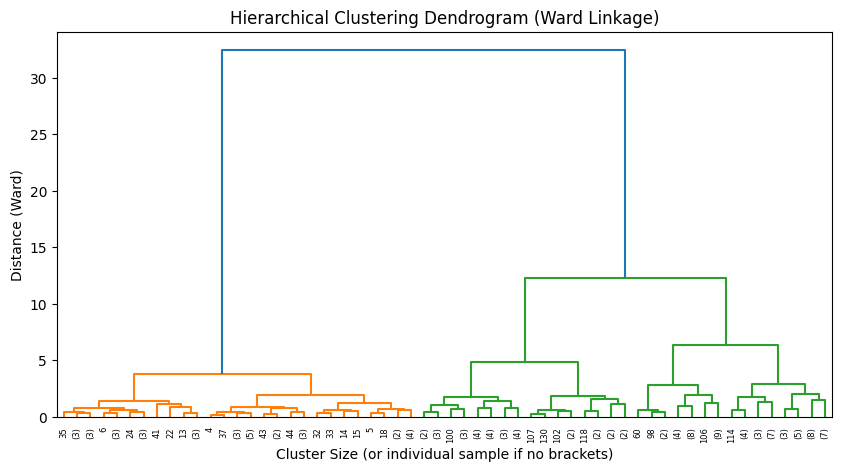

In [5]:
plt.figure(figsize=(10, 5))
dendrogram(linked_ward,truncate_mode='level', p=5,show_leaf_counts=True)

plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Cluster Size (or individual sample if no brackets)")
plt.ylabel("Distance (Ward)")
plt.show()

# 2. Visually inspect the dendrogram you plotted and cut it at a height that results in 3 distinct clusters. Assign each data point to its cluster and print the number of samples in each cluster.<br><br><em><strong>Hint:</strong> Use scipy's fcluster() with the 'criterion' set to 'distance' and your chosen height.</em>

In [10]:
import pandas as pd
from scipy.cluster.hierarchy import fcluster

In [8]:
clusters_ward = fcluster(linked_ward, t=10, criterion="distance")
clusters_ward

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 2, 2, 2, 2, 3, 2, 2, 2,
       2, 2, 2, 3, 3, 2, 2, 2, 2, 3, 2, 3, 2, 3, 2, 2, 3, 3, 2, 2, 2, 2,
       2, 3, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 3], dtype=int32)

In [11]:
cluster_counts = pd.Series(clusters_ward).value_counts()
cluster_counts

3    64
1    50
2    36
Name: count, dtype: int64

# 3. Repeat the dendrogram plotting for the same data using 'single' and 'complete' linkage methods, and compare how the cluster shapes and heights differ from 'ward' linkage.<br><br><em><strong>Hint:</strong> Place all three dendrograms side by side for visual comparison.</em>

In [12]:
linked_single = linkage(X, method='single')
linked_complete = linkage(X, method='complete')

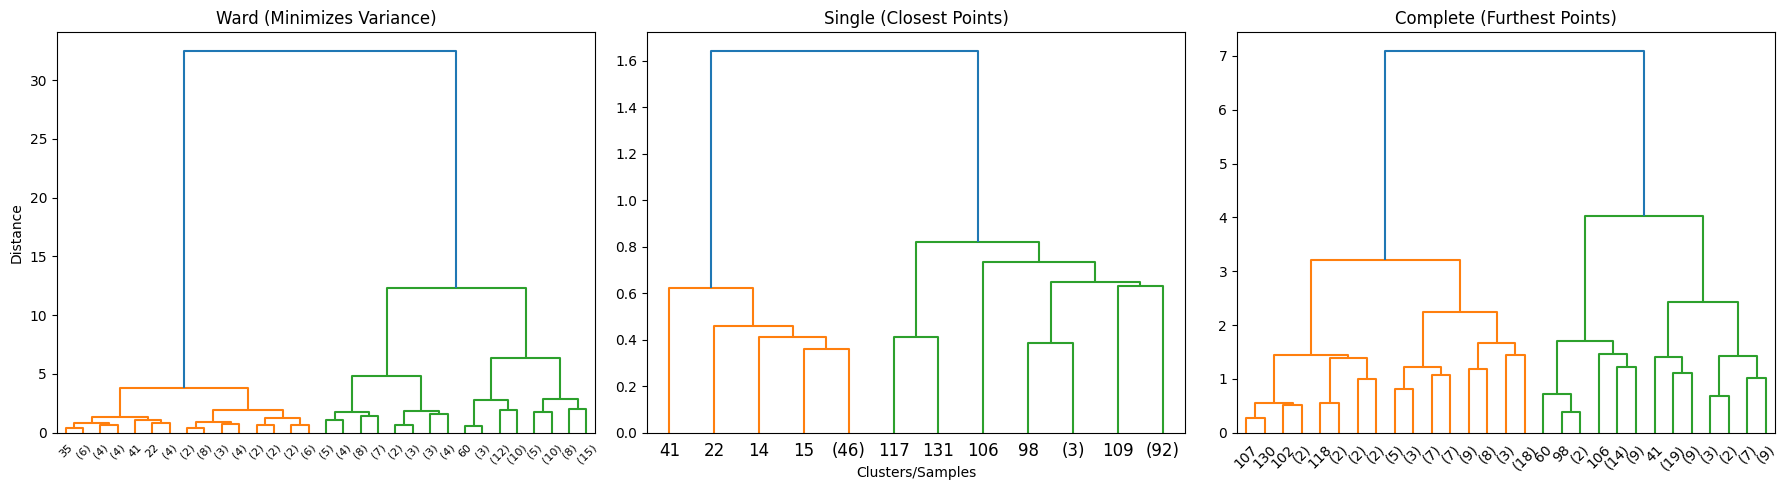

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

dendrogram(linked_ward, ax=axes[0], truncate_mode='level', p=4)
axes[0].set_title("Ward (Minimizes Variance)")
axes[0].set_ylabel("Distance")

dendrogram(linked_single, ax=axes[1], truncate_mode='level', p=4)
axes[1].set_title("Single (Closest Points)")
axes[1].set_xlabel("Clusters/Samples")

dendrogram(linked_complete, ax=axes[2], truncate_mode='level', p=4)
axes[2].set_title("Complete (Furthest Points)")

plt.tight_layout()
plt.show()

# 4. Interpret the dendrogram you created: Write a short explanation (3-4 lines) describing how you can tell which clusters are most similar and which are most different, based on the heights and structure of the branches.

In a dendrogram, the vertical height (y-axis) where two branches merge represents the distance or dissimilarity between those groups. Branches that merge at a very low height indicate clusters that are highly similar and closely packed together. Conversely, taller vertical lines before a merge signify that the resulting clusters are very distinct and far apart from one another.